# Student Academic Performance Prediction
### Linear Regression Model


## 1. Import All Libraries
We bring in all the tools (libraries) we need for this project in one place, right at the start.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score


## 2. Load the Dataset and Explore

In [2]:
df = pd.read_csv("student_performance_dataset.csv")
df.head()


,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [3]:
df.shape


(3000, 32)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

## 3. Handle Missing Values

In [5]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
city_type,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,60
doomscrolling_before_sleep,0


In [6]:
df.dropna(subset=["social_media_hours", "sleep_hours", "focus_score"], inplace=True)


## 4. Remove Columns We Do Not Need

In [7]:
df.drop(columns=["student_id", "performance_category"], inplace=True, errors='ignore')
df.head()


,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,...,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,...,1,10,6,Audio,Engineering,9,1,10,3,32
1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,...,4,2,6,Practical,Business,6,10,4,6,59
2,16,Female,Urban,4.3,7,54,57,4.3,1,82,...,9,1,9,Visual,Engineering,7,9,8,1,34
3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,...,1,5,10,Reading,Medical,7,7,9,10,60
4,17,Female,Urban,4.1,3,100,81,2.6,0,8,...,9,5,6,Visual,Medical,4,10,7,9,77


## 5. Detect Outliers (Using Boxplots)

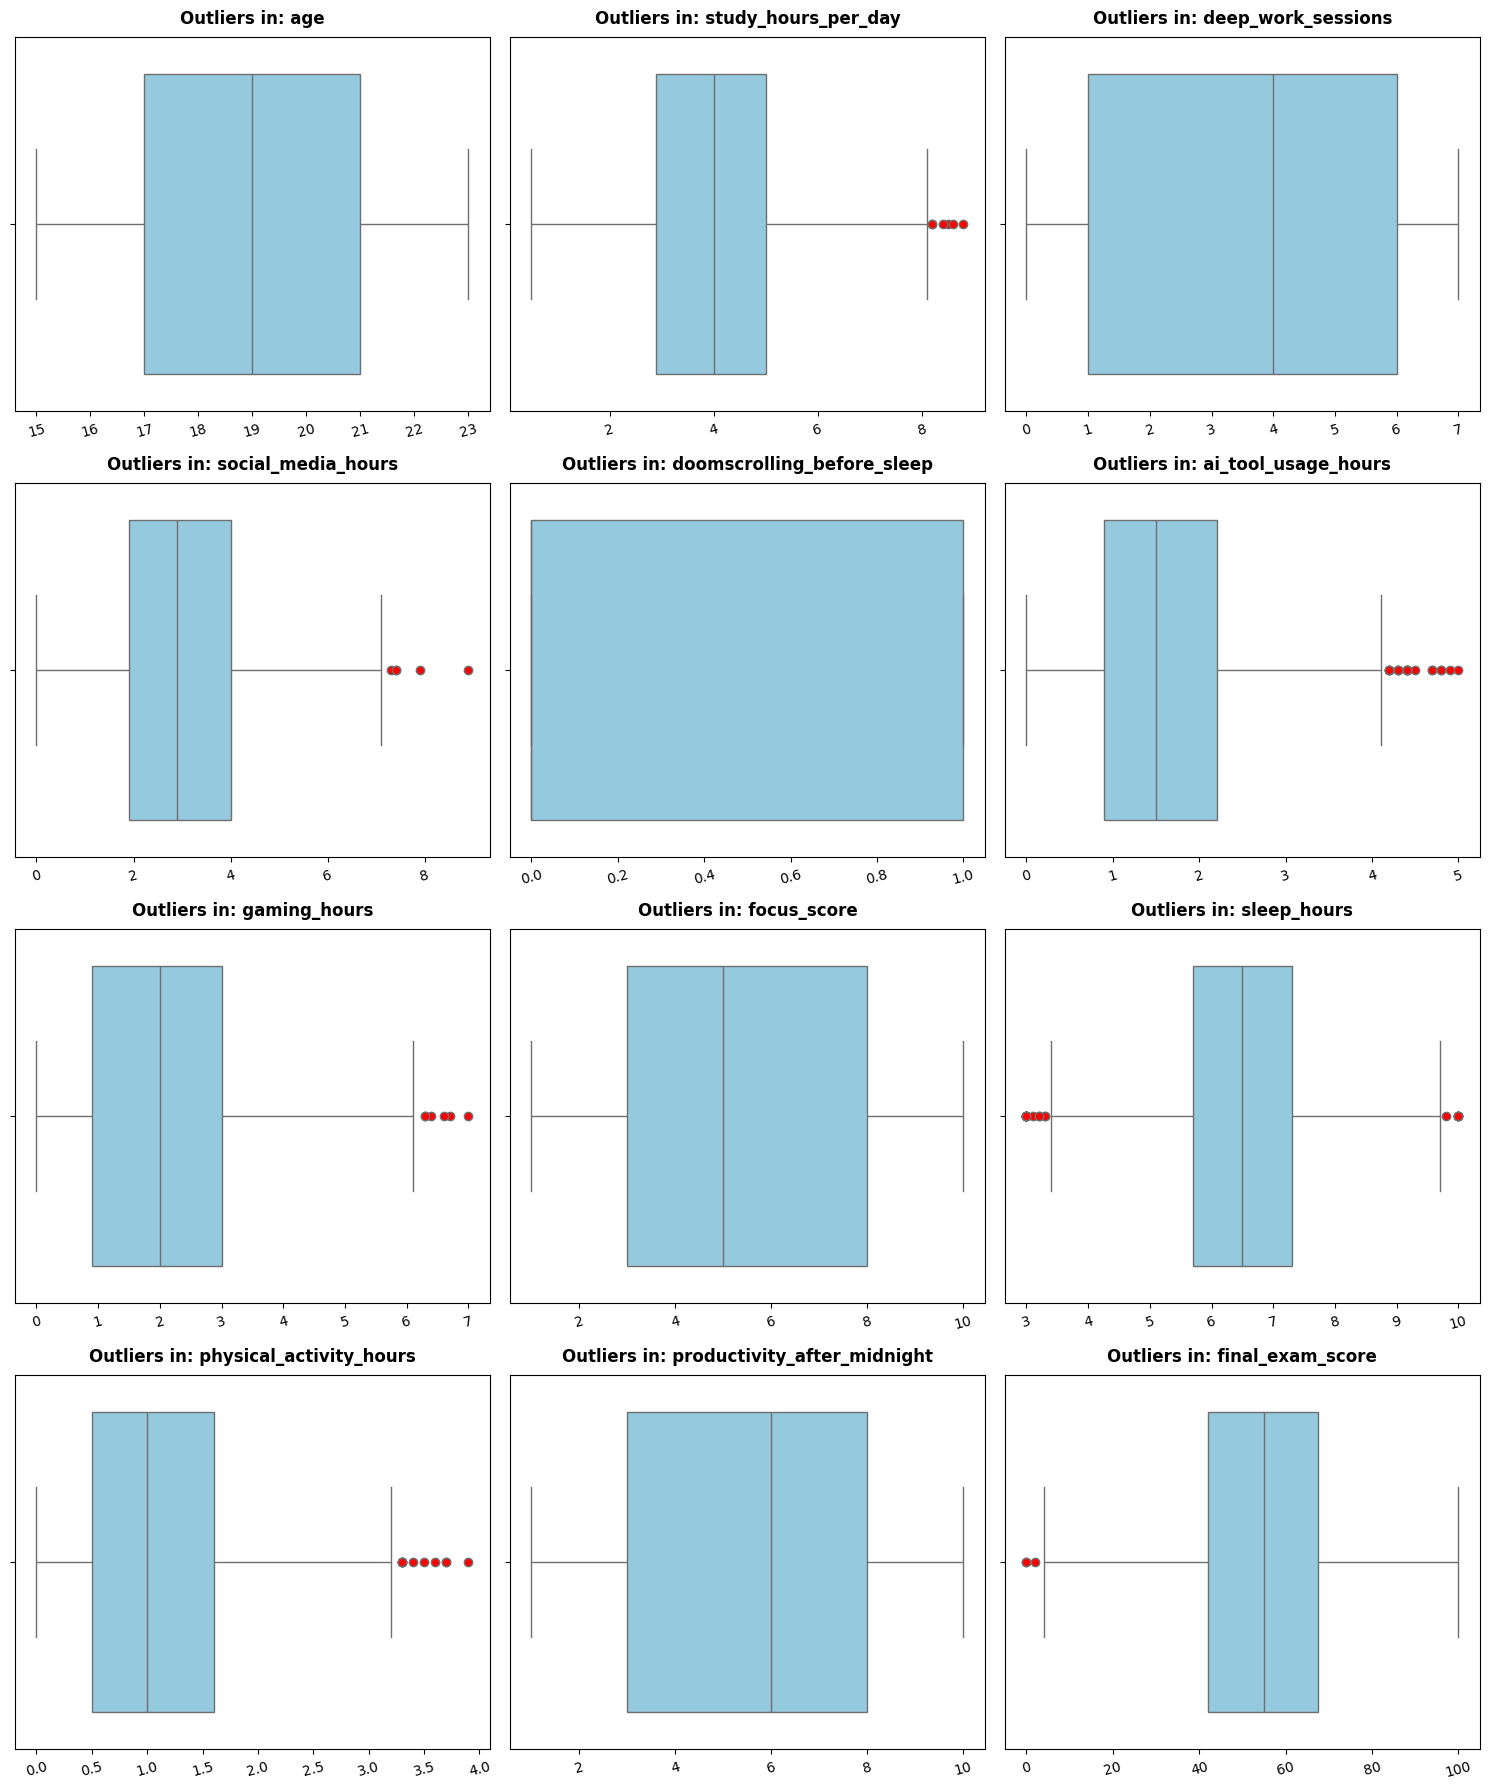

In [8]:
# List of columns we want to check for outliers
necessary_cols = [
    'age',
    'study_hours_per_day',
    'deep_work_sessions',
    'social_media_hours',
    'doomscrolling_before_sleep',
    'ai_tool_usage_hours',
    'gaming_hours',
    'focus_score',
    'sleep_hours',
    'physical_activity_hours',
    'productivity_after_midnight',
    'final_exam_score'
]

# 3 charts per row
num_features = len(necessary_cols)
rows = (num_features // 3) + (num_features % 3 > 0)

plt.figure(figsize=(15, rows * 4.5))

for i, col in enumerate(necessary_cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(x=df[col], color='skyblue', flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6})

    plt.title(f'Outliers in: {col}', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 6. Fix Outliers (Capping Method)
Instead of deleting outlier rows, we cap them. This means any value that is too high or too low gets pulled back to a normal limit, using the IQR rule.

In [9]:
# Columns where we want to cap extreme values
cols_to_cap = [
    'study_hours_per_day',
    'social_media_hours',
    'ai_tool_usage_hours',
    'gaming_hours',
    'sleep_hours',
    'physical_activity_hours',
    'productivity_after_midnight',
    'final_exam_score'
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR


    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])


## 7. One-Hot Encoding

In [10]:
cols_to_encode = ['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal']

cols_to_encode = [col for col in cols_to_encode if col in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

#check that no text columns are left in the data
print(df.select_dtypes(include=['object']).columns)


Index([], dtype='object')


## 8. Check Correlation

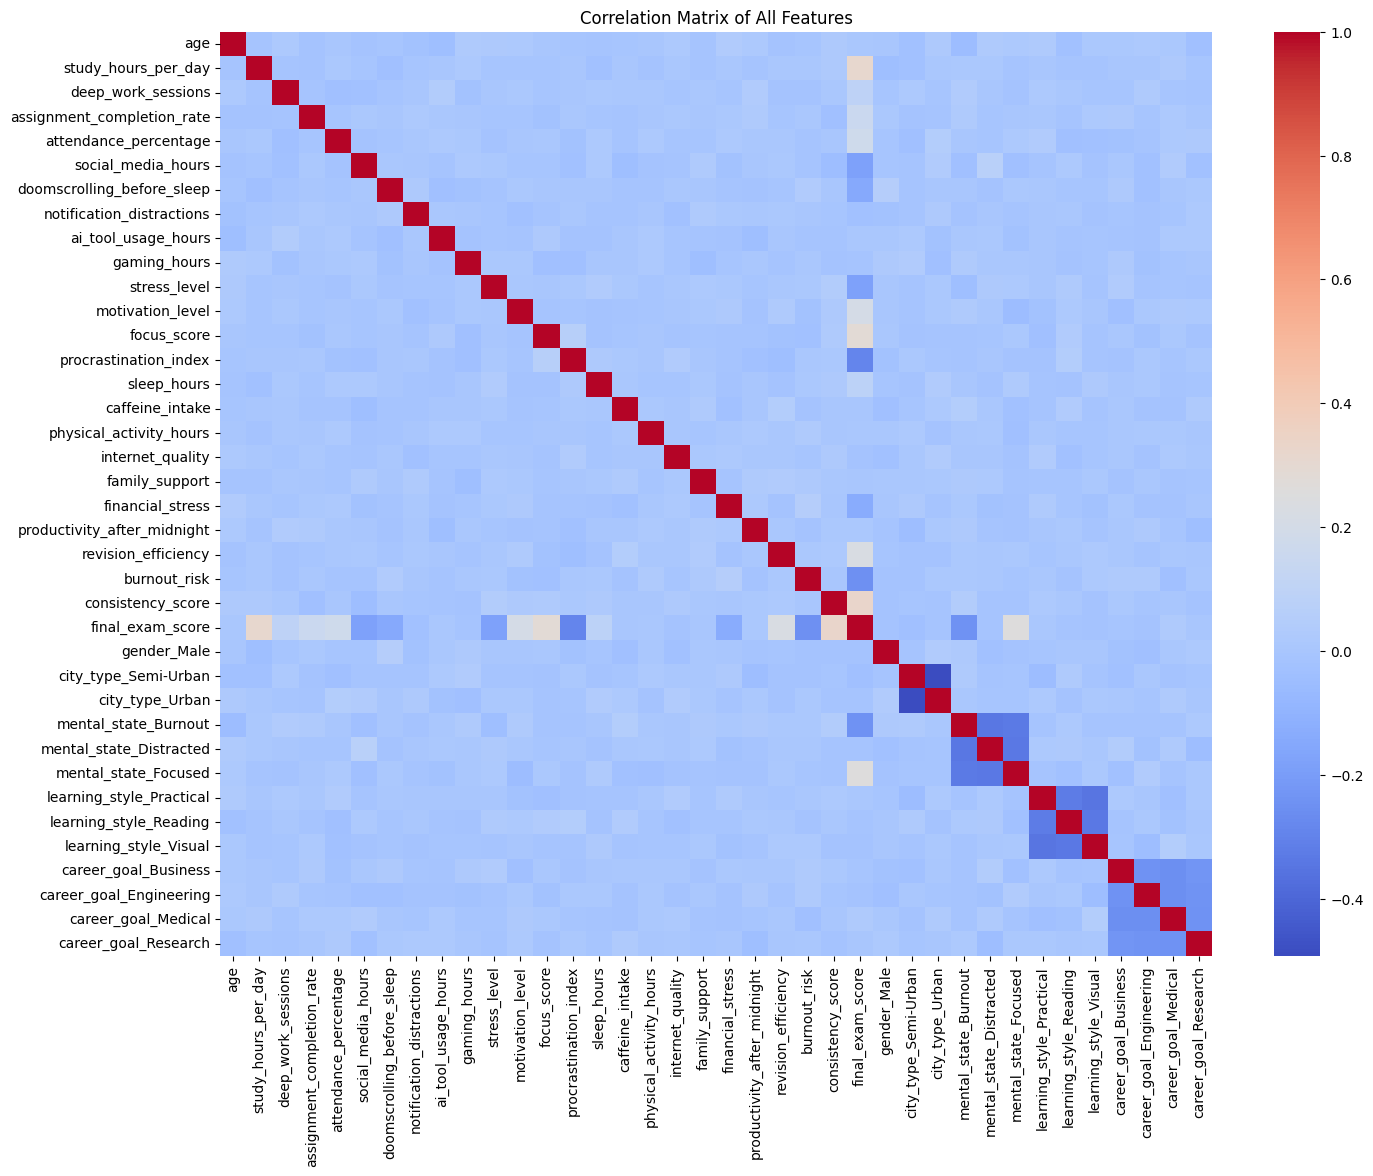

In [11]:
plt.figure(figsize=(16, 12))

sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of All Features")
plt.show()


## 9. Check VIF
VIF (Variance Inflation Factor) tells us if two or more columns are giving the model almost the same information. A high VIF means a column might be repeating info from another column.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

vif = pd.DataFrame()
vif["Feature"] = X.columns

# Calculate the VIF score for each column, only if all columns are numbers
if not X.empty and X.select_dtypes(include=np.number).shape[1] == X.shape[1]:
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
else:
    print("Warning: X is empty or contains non-numeric data, VIF calculation skipped.")

vif.sort_values(by=["VIF"], ascending=False).head(7)


,Feature,VIF
0,age,41.793049
14,sleep_hours,26.622058
4,attendance_percentage,24.348681
3,assignment_completion_rate,15.673384
1,study_hours_per_day,7.859116
19,financial_stress,4.802595
22,burnout_risk,4.784501


## 10. Build the Base line model

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled, y_train)


LinearRegression()

## 11. Make Predictions

In [17]:
y_pred = model.predict(x_test_scaled)
print(y_pred)

[ 24.65922233  80.57973934  49.48290114  67.98571544  60.83728519
  24.60469883  40.0827799   70.96162677  93.92190502  54.3459225
  50.61605526  34.11420801  23.80030974  40.7441246   68.57612336
  73.50576896  82.75491773  61.15561039  60.04330285  50.16571867
  44.93221544  47.54166488  74.10883407  51.47456553  91.30999109
  43.25090936  45.09342637  37.53114953  57.81958556  43.35302211
  52.2620715   58.57606513  20.75349175  40.12698311  35.20962438
  66.29203651  63.69068599  47.37581745  77.0366582   64.46869207
  66.88714975  77.90160188  73.569122    45.49406033  28.77095452
  58.79196376  44.59656463  62.558158    56.13519725  14.1762578
  58.77941216  73.58074684  32.59331773  52.63558277  66.99060689
  88.05924292  56.91823831  86.86448592  47.25371237  47.66291153
  45.02810634  17.7926383   74.40828819  50.99698173  28.55312457
  73.62955825  44.33571548  41.67212864  39.15494385  49.3011897
  55.90579254  90.04611741  72.62280379  54.49696808  54.63540805
  75.77041608

## 12. Model Evaluation

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2_score_value = r2_score(y_test, y_pred)
print(f"R2 Score : {r2_score_value}")

n = len(y_test)
p = x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2_score_value) * (n - 1)) / (n - p - 1)
print("Adjusted R² :", round(adjusted_r2, 4))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score : {r2_score_value}")
print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Squared Error : {rmse}")


R2 Score : 0.8233744002074643
Adjusted R² : 0.811
R2 Score : 0.8233744002074643
Mean Absolute Error : 6.296443283924244
Mean Squared Error : 65.04378193963343
Root Mean Squared Error : 8.064972531858583


## 13. Find the Best Number of Features
RFE (Recursive Feature Elimination) helps us find which columns are most useful for the prediction. Here we do a quick test asking it to pick the best 10 columns.
Instead of guessing, we test many different numbers of features (from 15 up to the maximum) and record the results, so we can see which number of features gives the best model.

In [21]:
results = []

# Try every number of features from 15 up to the total number of columns
for n_features in range(15, x_train.shape[1] + 1):

    # Apply RFE
    rfe = RFE(
        estimator=LinearRegression(),
        n_features_to_select=n_features
    )
    rfe.fit(x_train, y_train)

    # Get the columns that RFE picked
    selected = x_train.columns[rfe.support_]

    # Cross-validated R2 using training data only (no test-set leakage here)
    cv_scores = cross_val_score(LinearRegression(), x_train[selected], y_train, cv=5, scoring='r2')
    cv_r2 = cv_scores.mean()

    # Build a smaller dataset using only the selected columns
    x_train_new = x_train[selected]
    x_test_new = x_test[selected]

    model = LinearRegression()
    model.fit(x_train_new, y_train)

    # Predict
    y_pred = model.predict(x_test_new)

    # Model Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    p = x_test_new.shape[1]
    adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    # Save ONE combined row per n_features
    results.append([
        n_features,
        cv_r2,
        mae,
        mse,
        rmse,
        r2,
        adj_r2
    ])

# making result's dataframe
results_df = pd.DataFrame(
    results,
    columns=[
        "Features",
        "CV_R2",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Adjusted_R2"
    ]
)

# Sort by CV_R2 — this is the metric that hasn't touched the test set
results_df = results_df.sort_values(by="CV_R2", ascending=False)

print(results_df)

    Features     CV_R2       MAE        MSE      RMSE        R2  Adjusted_R2
9         24  0.804595  6.325593  65.605951  8.099750  0.821848     0.813930
11        26  0.804594  6.311915  65.345523  8.083658  0.822555     0.813980
10        25  0.804577  6.321603  65.503075  8.093397  0.822127     0.813877
12        27  0.804371  6.309596  65.321094  8.082147  0.822621     0.813703
13        28  0.804231  6.310257  65.311995  8.081584  0.822646     0.813381
14        29  0.804118  6.310992  65.320404  8.082104  0.822623     0.813008
15        30  0.804033  6.323373  65.638363  8.101751  0.821760     0.811746
16        31  0.803820  6.319306  65.437048  8.089317  0.822306     0.811972
17        32  0.803785  6.316166  65.376707  8.085586  0.822470     0.811792
18        33  0.803697  6.318156  65.378678  8.085708  0.822465     0.811432
21        36  0.803297  6.297002  65.052451  8.065510  0.823351     0.811307
19        34  0.803248  6.317460  65.375541  8.085514  0.822474     0.811085

Although the 24-feature model achieved the highest cross-validation R² by a negligible margin (0.804595 vs. 0.804594), the 26-feature model produced lower prediction errors (MAE and RMSE) and the highest Adjusted R². Therefore, the model with 26 selected features was chosen as the final model because it provided the best overall balance between prediction accuracy, model fit, and generalization.

## 14. Pick the Final Set of Selected Features by RFE
Based on the results above, 26 features gave the best balance of accuracy and simplicity. We now ask RFE to select exactly those 26 best columns.

In [22]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=26)
rfe.fit(x_train, y_train)

# Get the names of the selected features
selected_features = x_train.columns[rfe.support_]

print("Selected Features:\n")

for feature in selected_features:
    print(feature)

Selected Features:

study_hours_per_day
deep_work_sessions
assignment_completion_rate
attendance_percentage
social_media_hours
doomscrolling_before_sleep
ai_tool_usage_hours
stress_level
motivation_level
focus_score
procrastination_index
sleep_hours
physical_activity_hours
financial_stress
revision_efficiency
burnout_risk
consistency_score
city_type_Semi-Urban
mental_state_Burnout
mental_state_Distracted
mental_state_Focused
learning_style_Practical
learning_style_Reading
learning_style_Visual
career_goal_Business
career_goal_Engineering


## 15. Train and Evaluate the Final Model using 26 Features

In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selected by RFE
selected_features = [
    'study_hours_per_day',
    'deep_work_sessions',
    'assignment_completion_rate',
    'attendance_percentage',
    'social_media_hours',
    'doomscrolling_before_sleep',
    'ai_tool_usage_hours',
    'stress_level',
    'motivation_level',
    'focus_score',
    'procrastination_index',
    'sleep_hours',
    'physical_activity_hours',
    'financial_stress',
    'revision_efficiency',
    'burnout_risk',
    'consistency_score',
    'city_type_Semi-Urban',
    'mental_state_Burnout',
    'mental_state_Distracted',
    'mental_state_Focused',
    'learning_style_Practical',
    'learning_style_Reading',
    'learning_style_Visual',
    'career_goal_Business',
    'career_goal_Engineering'
]

x_train = x_train[selected_features]
x_test = x_test[selected_features]

model = LinearRegression()
model.fit(x_train, y_train)

#Predict
y_pred = model.predict(x_test)

#Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("=" * 45)
print("Linear Regression with RFE Selected Features")
print("=" * 45)
print(f"Number of Features : {p}")
print(f"MAE                : {mae:.4f}")
print(f"MSE                : {mse:.4f}")
print(f"RMSE               : {rmse:.4f}")
print(f"R² Score           : {r2:.4f}")
print(f"Adjusted R²        : {adjusted_r2:.4f}")


Linear Regression with RFE Selected Features
Number of Features : 26
MAE                : 6.3119
MSE                : 65.3455
RMSE               : 8.0837
R² Score           : 0.8226
Adjusted R²        : 0.8140


## 16. Visualize Actual vs Predicted Scores

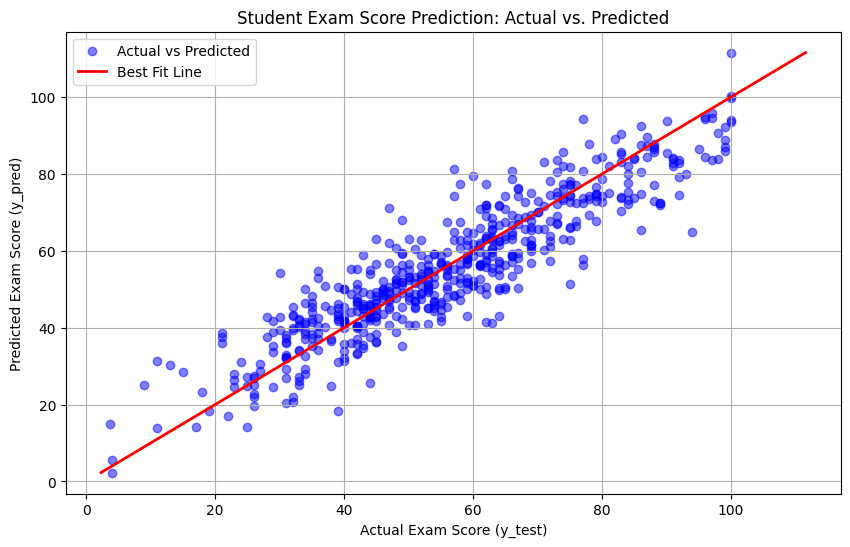

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Actual vs Predicted')

# Draw the perfect prediction line of our final linear regression model
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Best Fit Line')

# Label the chart
plt.xlabel("Actual Exam Score (y_test)")
plt.ylabel("Predicted Exam Score (y_pred)")
plt.title("Student Exam Score Prediction: Actual vs. Predicted")
plt.legend()
plt.grid(True)
plt.show()

This graph visually checks the accuracy of a machine learning model by plotting students' actual exam scores against the model's predicted scores (represented by the blue dots). The diagonal red line represents a perfect prediction where the actual score exactly matches the predicted score. Because the blue dots cluster tightly around this red line across the entire chart, it means the model is doing an excellent job and predicting the exam scores with high accuracy.

## 17. Project Summary

**What I did:**
I built a Linear Regression model to predict a student's final exam score based on their study habits, lifestyle, and mental state (for example, study hours, sleep, social media use, stress level, and more).

**How I did it, step by step:**
1. **Loaded the data** from a CSV file and looked at its size, column types, and missing values.
2. **Cleaned the data** by removing rows with missing values in key columns, and dropping columns that were not useful (like the student ID).
3. **Checked for outliers** using boxplots, then fixed them by "capping" extreme values instead of deleting them, so we keep as much data as possible.
4. **Converted text columns into numbers** (like gender and learning style) using one-hot encoding, since the model can only understand numbers.
5. **Studied the relationships between columns** using a correlation heatmap and checked for repeated information between columns using VIF (Variance Inflation Factor).
6. **Split the data** into a training set (80%) and a testing set (20%), and scaled the numbers so all columns are on a fair, similar range.
7. **Trained a first Linear Regression model** and checked its accuracy using R², Adjusted R², MAE, MSE, and RMSE.
8. **Used RFE (Recursive Feature Elimination)** to find out which columns matter most, testing different numbers of features to see which amount gives the best results.
9. **Trained a final model** using the best 26 features and measured its final performance.

**Result:**
The final model gives a clear, simple way to estimate a student's exam score based on their daily habits and mental state, using only the most useful and important features found through testing.
